In [770]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

import xgboost as xgb

In [771]:
df = pd.read_csv('IBM-HR-Employee-Attrition.csv')

In [772]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [773]:
df["OverTime"] = df["OverTime"].map({"Yes": 1, "No": 0})

In [774]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [775]:
scale = 1_250_000 / df["MonthlyIncome"].min()

df["MonthlyRupiah"] = df["MonthlyIncome"] * scale
df["MonthlyRupiah"]= df["MonthlyRupiah"].round(0).astype(int)

In [776]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

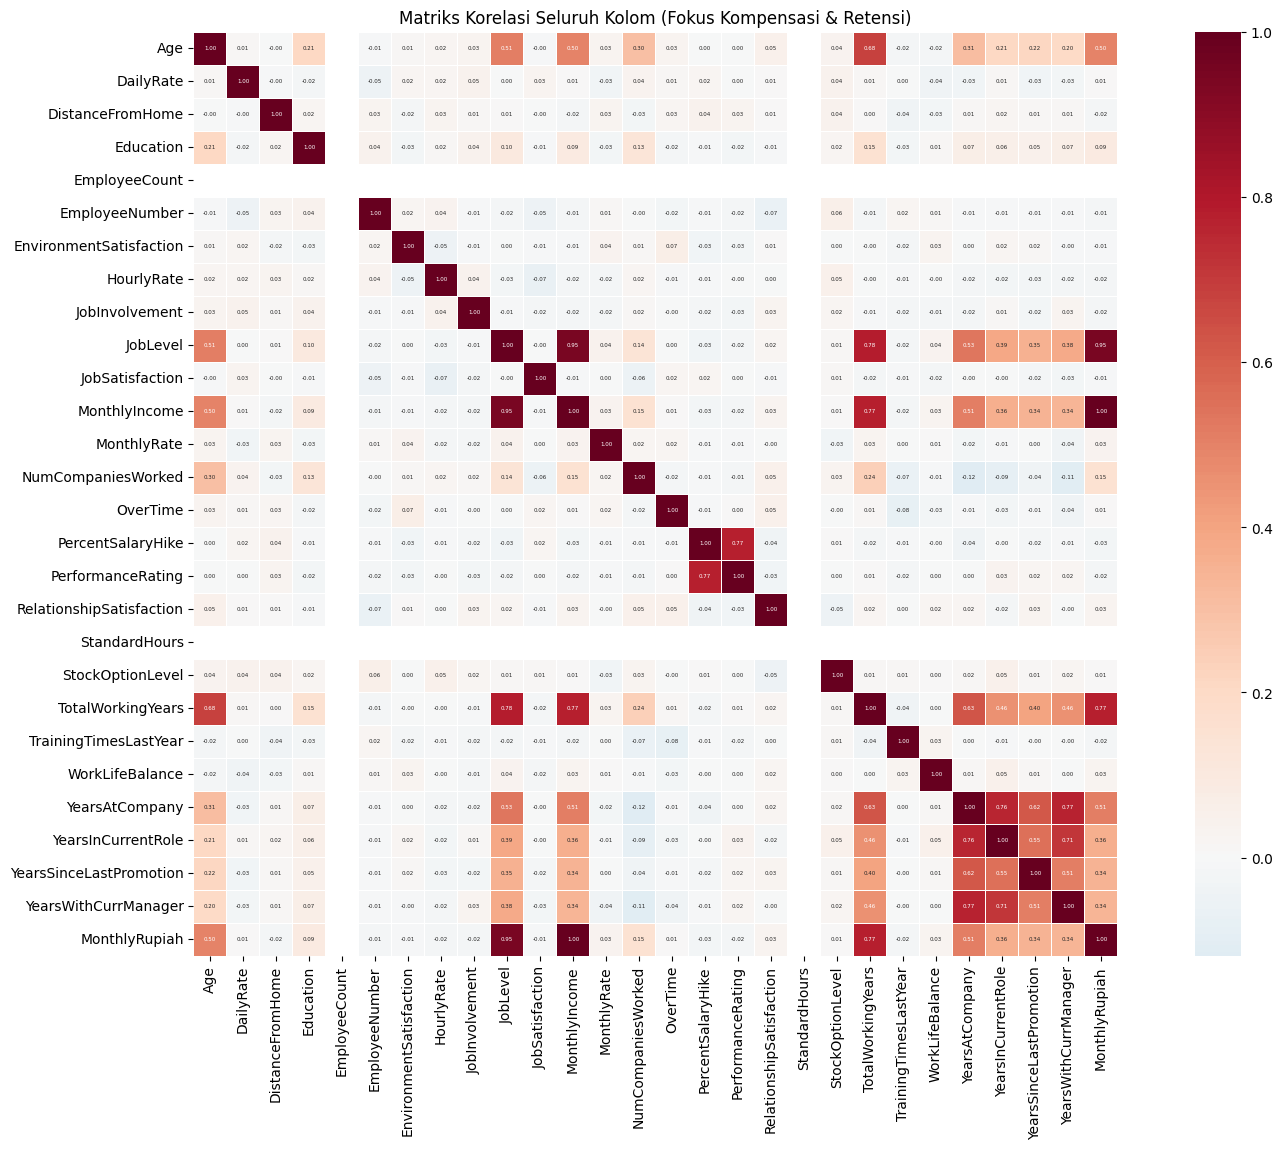

In [777]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(20, 12))

# Hitung matriks korelasi
corr_matrix = numeric_df.corr()

# Buat mask untuk menutupi bagian atas (agar tidak duplikat/simetris)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualisasi
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0,
            linewidths=0.5,
            square=True,
            annot_kws={"size": 4},)

plt.title("Matriks Korelasi Seluruh Kolom (Fokus Kompensasi & Retensi)")
plt.show()

In [778]:
df["PerformanceRating"].min()

np.int64(3)

In [779]:
df[df["PerformanceRating"] == 4]["PercentSalaryHike"].max()

np.int64(25)

# Create Synthetic Data for PerformanceRating 1 & 2

# Modeling

In [780]:
# 1. Features & Target

In [781]:
features = [
    'JobInvolvement',
    'JobLevel',
    'MonthlyIncome',
    'YearsAtCompany',
    'OverTime'
]

target = 'PercentSalaryHike'

X = df[features]
y = df[target]

In [782]:
# 2. Split

In [783]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [784]:
# 3. Sample weight (optional)

In [785]:
value_counts = y_train.value_counts()

weights = y_train.apply(lambda x: 1 / value_counts[x]).values

In [786]:
# 4. Model

In [787]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [788]:
# 5. Training

In [789]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [790]:
# 6. Prediction

In [791]:
predictions = model.predict(X_test)

In [792]:
# 7. Output

In [793]:
for i, pred in enumerate(predictions[:10]):
    print(f"Sample {i+1}: Predicted Salary Hike = {pred:.2f}%")

Sample 1: Predicted Salary Hike = 16.61%
Sample 2: Predicted Salary Hike = 13.84%
Sample 3: Predicted Salary Hike = 12.30%
Sample 4: Predicted Salary Hike = 13.31%
Sample 5: Predicted Salary Hike = 14.22%
Sample 6: Predicted Salary Hike = 12.69%
Sample 7: Predicted Salary Hike = 20.27%
Sample 8: Predicted Salary Hike = 19.45%
Sample 9: Predicted Salary Hike = 15.26%
Sample 10: Predicted Salary Hike = 17.23%


In [794]:
print(y.describe())

count    1470.000000
mean       15.209524
std         3.659938
min        11.000000
25%        12.000000
50%        14.000000
75%        18.000000
max        25.000000
Name: PercentSalaryHike, dtype: float64


In [795]:
# 6. Prediksi
y_pred = model.predict(X_test)

In [796]:
# 7. Evaluasi
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [733]:
# Membuat skenario untuk diuji
# Urutan kolom harus SAMA dengan X_train: 
# ['JobInvolvement', 'JobLevel', 'MonthlyIncome', 'YearsAtCompany', 'OverTime']

scenarios = pd.DataFrame([
    # Kasus A: Karyawan Ideal (High Involvement, Low Income - Harusnya Hike Tinggi)
    [4, 1, 3000, 2, 1], 
    
    # Kasus B: Karyawan Senior "Nyaman" (Low Involvement, High Income - Harusnya Hike Rendah/Stabil)
    [1, 4, 15000, 15, 0],
    
    # Kasus C: Karyawan Baru, Sangat Rajin tapi Gaji Standar
    [4, 1, 4000, 1, 1],
    
    # Kasus D: Karyawan Senior tapi tetap Rajin & Lembur
    [4, 4, 16000, 20, 1]
], columns=X.columns)

# Prediksi menggunakan model Anda
predictions = model.predict(scenarios)

# Tampilkan hasil
for i, pred in enumerate(predictions):
    print(f"Scenario {chr(65+i)}: {pred:.2f}%")

Scenario A: 11.71%
Scenario B: 15.49%
Scenario C: 12.63%
Scenario D: 16.84%


In [734]:
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Absolute Error: 3.45
R-squared Score: -0.44


In [735]:
# Cek Sensitivitas: Apa yang terjadi jika orang yang sama tiba-tiba Lembur?
karyawan_x = pd.DataFrame([[3, 2, 6000, 5, 0]], columns=X.columns) # OverTime = No
karyawan_x_lembur = pd.DataFrame([[3, 2, 6000, 5, 1]], columns=X.columns) # OverTime = Yes

hike1 = model.predict(karyawan_x)[0]
hike2 = model.predict(karyawan_x_lembur)[0]

print(f"Hike Tanpa Lembur: {hike1:.2f}%")
print(f"Hike Dengan Lembur: {hike2:.2f}%")
print(f"Selisih (Impact OverTime): {hike2 - hike1:.2f}%")

Hike Tanpa Lembur: 12.98%
Hike Dengan Lembur: 11.92%
Selisih (Impact OverTime): -1.06%


In [736]:
# Mendapatkan importance berdasarkan GAIN (paling akurat secara logika bisnis)
importance_gain = model.get_booster().get_score(importance_type='gain')

# Masukkan ke DataFrame
df_gain = pd.DataFrame({
    "Feature": list(importance_gain.keys()),
    "Importance": list(importance_gain.values())
}).sort_values(by="Importance", ascending=False)

print(df_gain)

          Feature  Importance
2   MonthlyIncome    4.236535
3  YearsAtCompany    3.014910
4        OverTime    2.452426
0  JobInvolvement    2.085562
1        JobLevel    1.948430


In [737]:
importance = model.feature_importances_
df_importance = pd.DataFrame({
    "Feature": X.columns, 
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# 3. Menampilkan tabel 2 kolom
print("Tabel Fitur Importance:")
print(df_importance)

Tabel Fitur Importance:
          Feature  Importance
2   MonthlyIncome    0.308384
3  YearsAtCompany    0.219460
4        OverTime    0.178516
0  JobInvolvement    0.151811
1        JobLevel    0.141829


# Model Evaluation (Metrics)

In [738]:
### Compare MAE train and test

In [739]:
mean_absolute_error(y_test, y_pred)

3.4464850425720215

In [740]:
### RMSE

In [745]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE: ", rmse)

RMSE:  4.357828939413013


In [693]:
### R2 Score

In [747]:
r2 = r2_score(y_test, y_pred)
print("R2 Score: ", r2)

R2 Score:  -0.4395946264266968


In [694]:
### Prediction Distribution Check

In [748]:
pd.Series(y_pred).describe()

count    294.000000
mean      15.080736
std        2.364941
min       10.144861
25%       13.325515
50%       14.739796
75%       16.771791
max       22.445620
dtype: float64

In [695]:
### Band consistency check

In [749]:
np.sum((y_pred < 11) | (y_pred > 25))

np.int64(6)

In [768]:
### Error per segment

In [769]:
df_test["error"] = y_test - y_pred
df_test.groupby("JobLevel")["error"].mean()

ValueError: operands could not be broadcast together with shapes (368,) (294,) 

In [753]:
### scenario sanity check (qualitative validation (business validation))

In [754]:
### Feature Importance

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

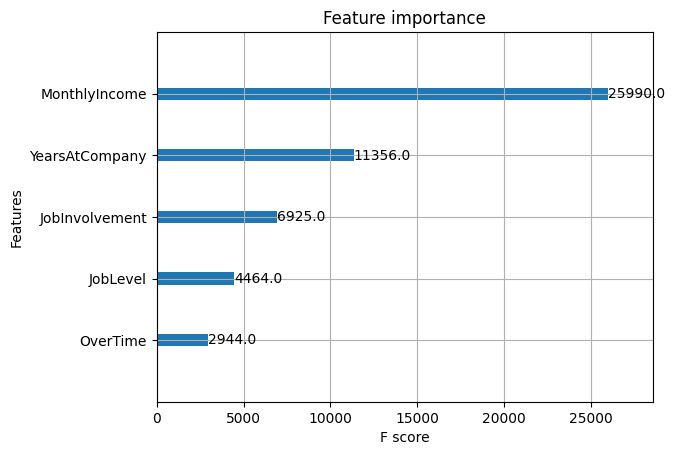

In [755]:
xgb.plot_importance(model)

In [756]:
model.feature_importances_

array([0.15181123, 0.14182918, 0.30838382, 0.21945992, 0.17851585],
      dtype=float32)

In [761]:
### Overfitting check
train_pred = model.predict(X_train)

print("Train MAE: ", mean_absolute_error(y_train, train_pred))
print("Test MAE: ", mean_absolute_error(y_test, y_pred))

# Kondisi:
# - train < test = good
# - tain jauh lebih kecil ==== overfit
# - dua2 nya jelek === underfit

Train MAE:  0.4652479588985443
Test MAE:  3.4464850425720215


In [762]:
### Residual analysis

In [763]:
residual - y_test - y_pred

NameError: name 'residual' is not defined

In [764]:
### Stability Check

In [765]:
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=i)
    model.fit(X_train, y_train)
    print(r2_score(y_test, model.predict(X_test)))

-0.4031916856765747
-0.510262131690979
-0.4713236093521118
-0.44123876094818115
-0.5072727203369141


In [ ]:
# Benchmark model sederhana

In [767]:
baseline = np.mean(y_train)
print(baseline)

15.227767695099818
